# Distribution Comparison Summary: Hub, Long Chain, Random DAG, and Sachs

This notebook visualizes distributional comparison results for the Hub, Long Chain, Random DAG, and Sachs experiments.

Each experiment compares two diffusion frameworks plus one competitor across sample sizes:
- **Causality-Agnostic Diffusion**: joint diffusion model, evaluated as an observational conditional sampler
- **Causality-Encoded Diffusion**: causal group-wise diffusion model, evaluated as a post-intervention sampler
- **VACA**: competitor method loaded from the `vaca/` result files

The plots use two distributional metrics against fixed true do-reference samples:
- **Energy Distance**
- **RBF MMD^2** (`mmd2` in the result files)


In [10]:
#!/usr/bin/env python3
"""
Distribution Comparison Summary: Hub, Long Chain, Random DAG, and Sachs Analysis
Creates boxplots comparing energy distance and RBF MMD^2 across sample sizes
for distributional comparison experiments.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

# Set up plotting style
plt.style.use('default')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

# Define paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'simulations' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results'
HUB_DIR = RESULTS_DIR / 'hub_distribution_comparison'
LONG_CHAIN_DIR = RESULTS_DIR / 'long_chain_distribution_comparison'
RANDOM_DAG_DIR = RESULTS_DIR / 'random_dag_distribution_comparison'
SACHS_DIR = RESULTS_DIR / 'sachs_distribution_comparison'

print('Setup complete!')
print('Results directories:')
print(f'  Hub Distribution Comparison: {HUB_DIR}')
print(f'  Long Chain Distribution Comparison: {LONG_CHAIN_DIR}')
print(f'  Random DAG Distribution Comparison: {RANDOM_DAG_DIR}')
print(f'  Sachs Distribution Comparison: {SACHS_DIR}')


Setup complete!
Results directories:
  Hub Distribution Comparison: results/hub_distribution_comparison
  Long Chain Distribution Comparison: results/long_chain_distribution_comparison
  Random DAG Distribution Comparison: results/random_dag_distribution_comparison
  Sachs Distribution Comparison: results/sachs_distribution_comparison


## 1. Data Loading Functions

Load and prepare the per-seed distributional comparison results from the diffusion result files and the VACA competitor files.

In [11]:
METRIC_COLUMNS = ['energy_distance', 'mmd2']
REQUIRED_COLUMNS = ['seed', 'n_samples_train', 'framework', *METRIC_COLUMNS]
VACA_RESULTS_FILES = {
    'long_chain': RESULTS_DIR / 'long_chain_distribution_comparison' / 'vaca' / 'long_chain_vaca_results_qt.csv',
    'hub': RESULTS_DIR / 'hub_distribution_comparison' / 'vaca' / 'hub_vaca_results_qt.csv',
    'random_dag': RESULTS_DIR / 'random_dag_distribution_comparison' / 'vaca' / 'random_dag_vaca_results_edge0p5_qt.csv',
    'sachs': RESULTS_DIR / 'sachs_distribution_comparison' / 'vaca' / 'sachs_vaca_results_qt.csv',
}


def sorted_int_values(values):
    """Return sorted values as plain Python ints for cleaner notebook output."""

    return [int(value) for value in sorted(values)]


def load_distribution_data(experiment_name, scaler_suffix='_qt'):
    """Load distributional comparison data for one experiment."""

    experiment_dir = RESULTS_DIR / f'{experiment_name}_distribution_comparison'
    results_file = experiment_dir / f'{experiment_name}_distribution_comparison_results{scaler_suffix}.csv'

    if not results_file.exists():
        raise FileNotFoundError(f'Results file not found: {results_file}')

    df = pd.read_csv(results_file)

    if 'n_train' in df.columns and 'n_samples_train' not in df.columns:
        df = df.rename(columns={'n_train': 'n_samples_train'})

    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f'{results_file} is missing required columns: {missing}')

    df = df.copy()
    df['experiment'] = experiment_name

    print(f'{experiment_name.upper().replace("_", " ")} DISTRIBUTION COMPARISON dataset:')
    print(f'  File: {results_file}')
    print(f'  Shape: {df.shape}')
    print(f'  Sample sizes: {sorted_int_values(df["n_samples_train"].unique())}')
    print(f'  Frameworks: {sorted(df["framework"].unique())}')
    print(f'  Seeds: {len(df["seed"].unique())} seeds')
    print(f'  Energy distance range: {df["energy_distance"].min():.6f} - {df["energy_distance"].max():.6f}')
    print(f'  MMD^2 range: {df["mmd2"].min():.6f} - {df["mmd2"].max():.6f}')
    print()

    return df


def load_vaca_distribution_data(experiment_name):
    """Load VACA competitor data for one experiment."""

    results_file = VACA_RESULTS_FILES[experiment_name]

    if not results_file.exists():
        raise FileNotFoundError(f'VACA results file not found: {results_file}')

    df = pd.read_csv(results_file)

    if 'n_train' in df.columns and 'n_samples_train' not in df.columns:
        df = df.rename(columns={'n_train': 'n_samples_train'})

    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f'{results_file} is missing required columns: {missing}')

    df = df.copy()
    df['framework'] = 'vaca'
    df['experiment'] = experiment_name

    print(f'{experiment_name.upper().replace("_", " ")} VACA COMPETITOR dataset:')
    print(f'  File: {results_file}')
    print(f'  Shape: {df.shape}')
    print(f'  Sample sizes: {sorted_int_values(df["n_samples_train"].unique())}')
    print(f'  Frameworks: {sorted(df["framework"].unique())}')
    print(f'  Seeds: {len(df["seed"].unique())} seeds')
    print(f'  Energy distance range: {df["energy_distance"].min():.6f} - {df["energy_distance"].max():.6f}')
    print(f'  MMD^2 range: {df["mmd2"].min():.6f} - {df["mmd2"].max():.6f}')
    print()

    return df


def load_experiment_with_vaca(experiment_name, scaler_suffix='_qt'):
    """Load diffusion results plus VACA competitor rows for one experiment."""

    base_data = load_distribution_data(experiment_name, scaler_suffix)
    vaca_data = load_vaca_distribution_data(experiment_name)
    return pd.concat([base_data, vaca_data], ignore_index=True, sort=False)


def load_all_distribution_experiments(scaler_suffix='_qt'):
    """Load and combine all distributional comparison experiments."""

    print('Loading distributional comparison data...')
    print('=' * 60)

    long_chain_data = load_experiment_with_vaca('long_chain', scaler_suffix)
    hub_data = load_experiment_with_vaca('hub', scaler_suffix)
    random_dag_data = load_experiment_with_vaca('random_dag', scaler_suffix)
    sachs_data = load_experiment_with_vaca('sachs', scaler_suffix)

    combined_data = pd.concat(
        [long_chain_data, hub_data, random_dag_data, sachs_data],
        ignore_index=True,
    )

    print('COMBINED dataset:')
    print(f'  Total shape: {combined_data.shape}')
    print(f'  Experiments: {sorted(combined_data["experiment"].unique())}')
    print(f'  Frameworks: {sorted(combined_data["framework"].unique())}')
    print(f'  Sample sizes: {sorted_int_values(combined_data["n_samples_train"].unique())}')

    return combined_data, long_chain_data, hub_data, random_dag_data, sachs_data


# Load all data
combined_df, long_chain_df, hub_df, random_dag_df, sachs_df = load_all_distribution_experiments()

print('\n' + '=' * 60)
print(f'Total data points: {len(combined_df)}')
print('=' * 60)


Loading distributional comparison data...
LONG CHAIN DISTRIBUTION COMPARISON dataset:
  File: results/long_chain_distribution_comparison/long_chain_distribution_comparison_results_qt.csv
  Shape: (400, 21)
  Sample sizes: [500, 1000, 2000, 5000]
  Frameworks: ['conditional', 'standard']
  Seeds: 50 seeds
  Energy distance range: 0.011822 - 0.115021
  MMD^2 range: 0.001025 - 0.011696

LONG CHAIN VACA COMPETITOR dataset:
  File: results/long_chain_distribution_comparison/vaca/long_chain_vaca_results_qt.csv
  Shape: (200, 26)
  Sample sizes: [500, 1000, 2000, 5000]
  Frameworks: ['vaca']
  Seeds: 50 seeds
  Energy distance range: 0.045866 - 0.582107
  MMD^2 range: 0.004259 - 0.053482

HUB DISTRIBUTION COMPARISON dataset:
  File: results/hub_distribution_comparison/hub_distribution_comparison_results_qt.csv
  Shape: (400, 21)
  Sample sizes: [500, 1000, 2000, 5000]
  Frameworks: ['conditional', 'standard']
  Seeds: 50 seeds
  Energy distance range: 0.006714 - 0.390468
  MMD^2 range: 0.0004

## 2. Combined Distributional Metric Plots

Create separate 2x2 boxplot figures for Energy Distance and MMD^2, including VACA as the competitor method. Lower values are better for both metrics.

Creating 2x2 Energy Distance distributional comparison figure...
Energy Distance 2x2 figure saved to: results/distribution_comparison_energy_distance_2x2.pdf
Energy Distance 2x2 figure saved to: results/distribution_comparison_energy_distance_2x2.png


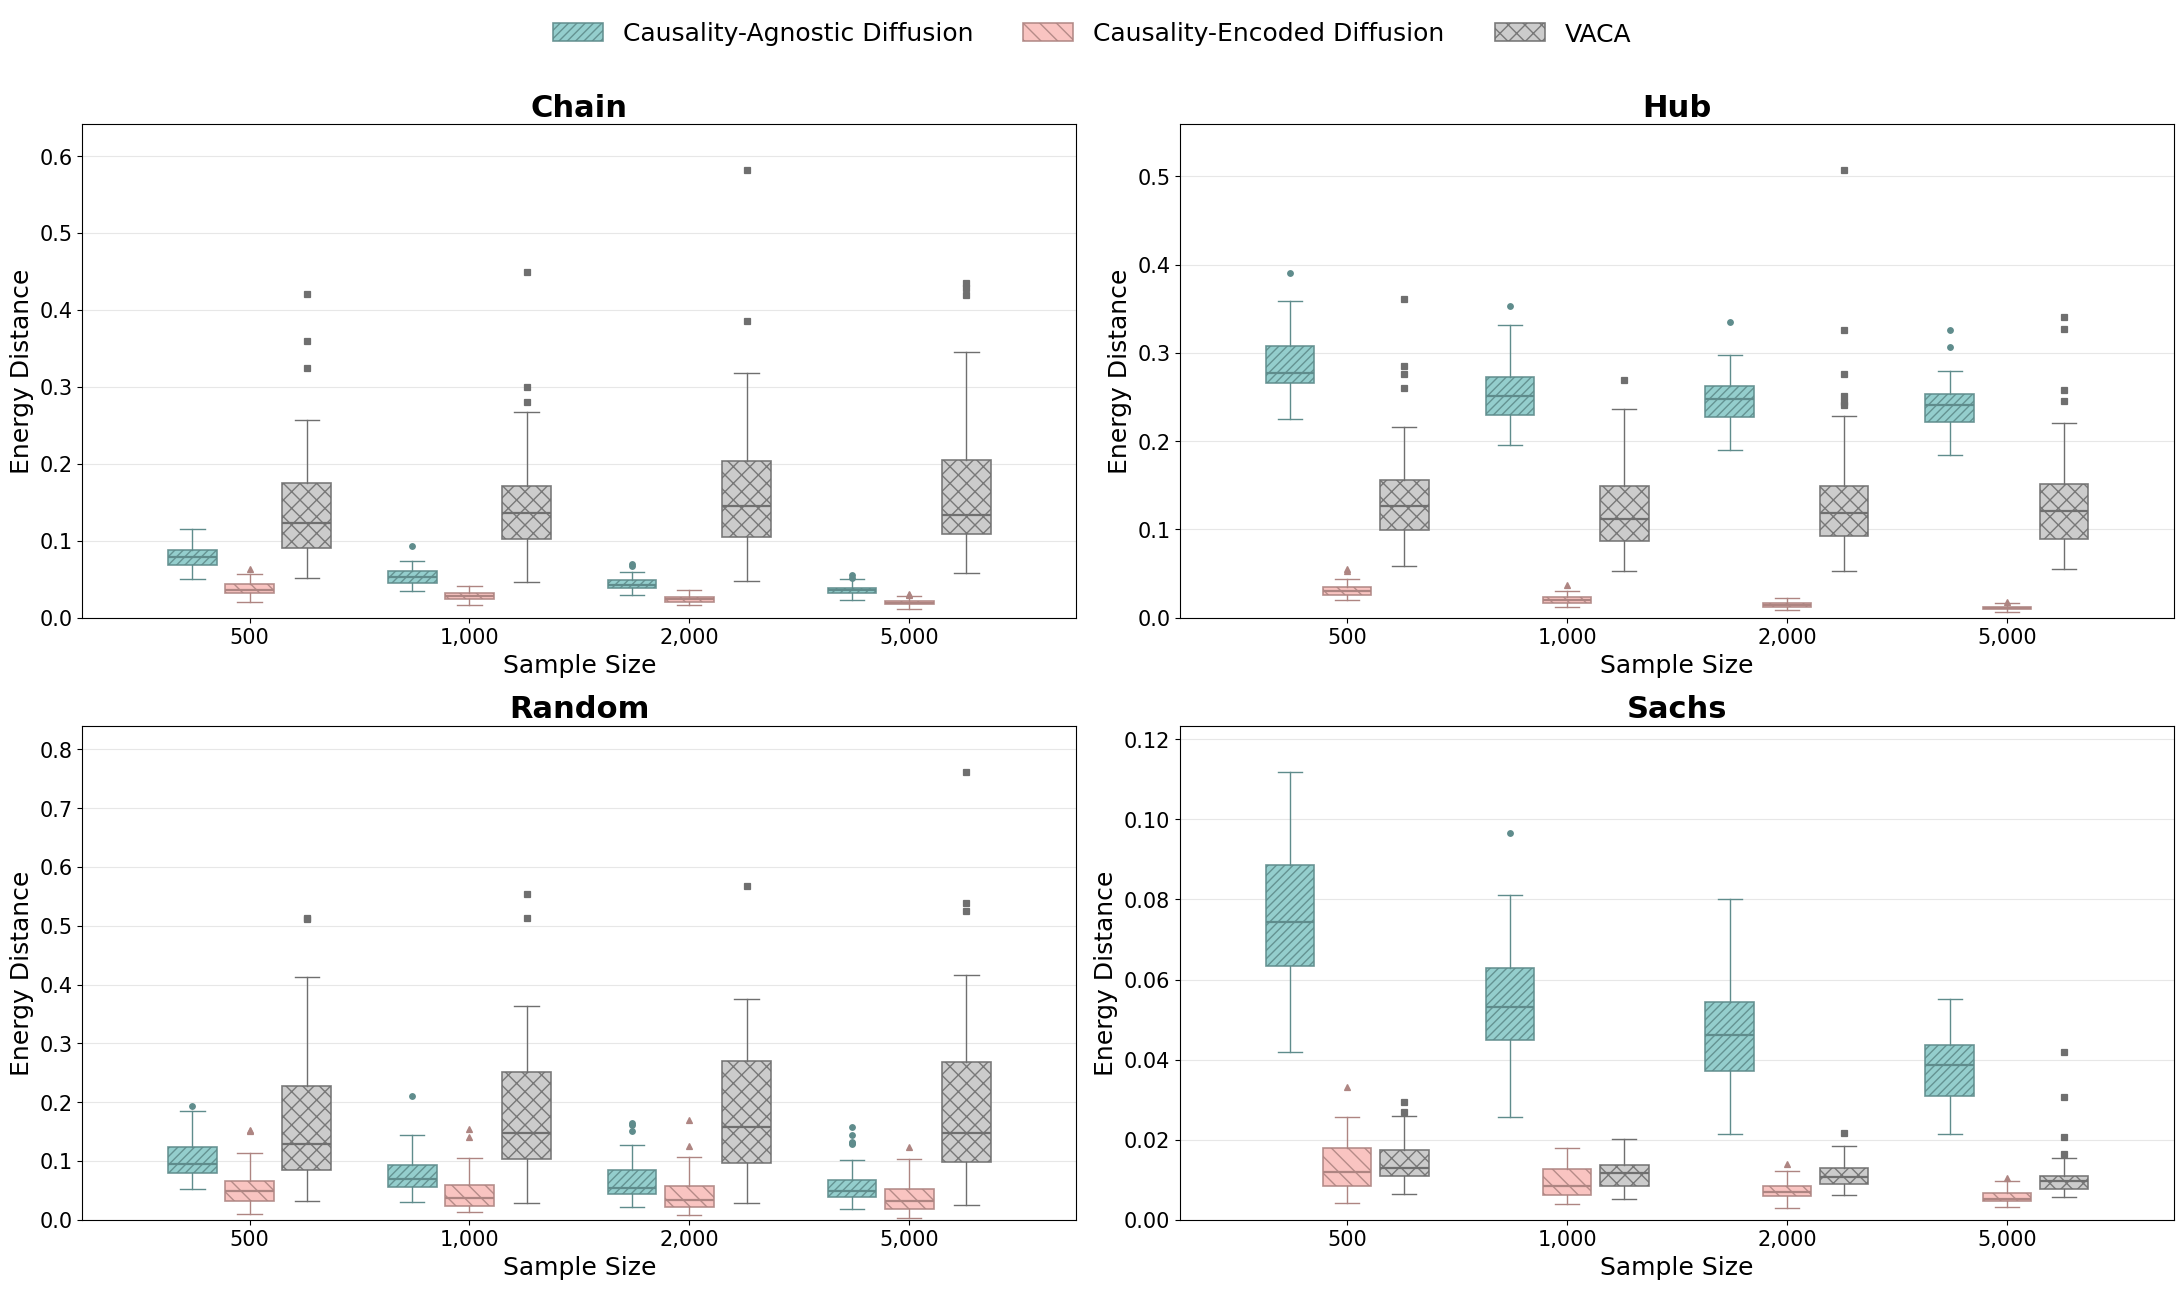

Creating 2x2 Squared MMD distributional comparison figure...
Squared MMD 2x2 figure saved to: results/distribution_comparison_mmd_2x2.pdf
Squared MMD 2x2 figure saved to: results/distribution_comparison_mmd_2x2.png


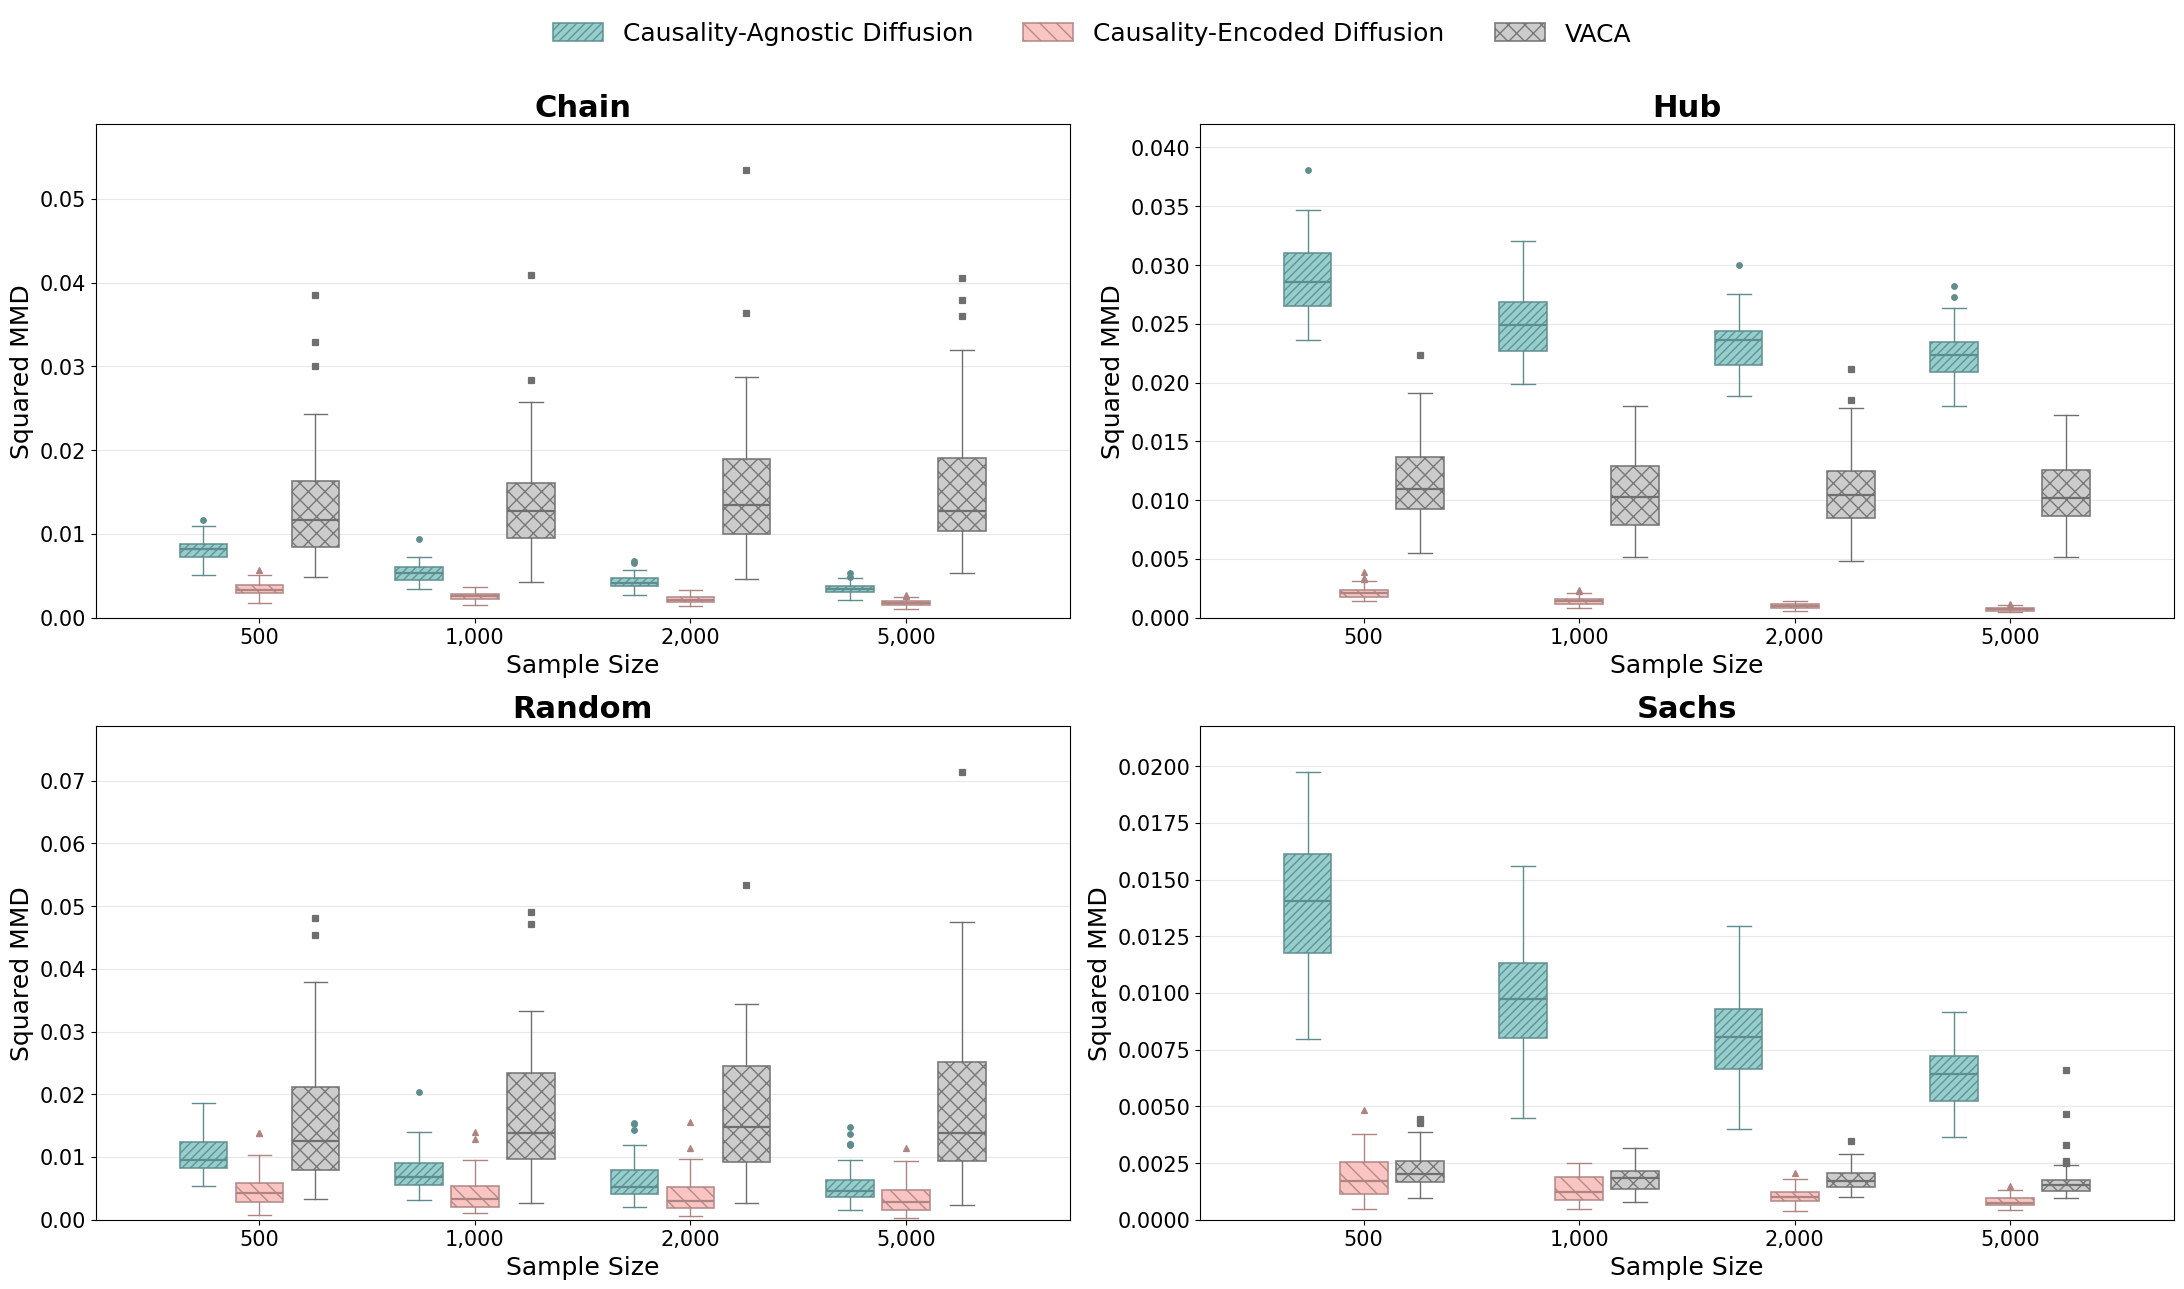


LONG CHAIN Energy Distance Summary Statistics:
------------------------------------------------------------

CAUSALITY-AGNOSTIC DIFFUSION:
  Sample Size 500: Mean=0.077849, Std=0.015399, N=50
  Sample Size 1,000: Mean=0.053516, Std=0.011221, N=50
  Sample Size 2,000: Mean=0.043594, Std=0.008662, N=50
  Sample Size 5,000: Mean=0.036173, Std=0.006575, N=50

CAUSALITY-ENCODED DIFFUSION:
  Sample Size 500: Mean=0.037752, Std=0.008642, N=50
  Sample Size 1,000: Mean=0.028369, Std=0.005681, N=50
  Sample Size 2,000: Mean=0.024409, Std=0.004731, N=50
  Sample Size 5,000: Mean=0.020044, Std=0.003935, N=50

VACA:
  Sample Size 500: Mean=0.142794, Std=0.077135, N=50
  Sample Size 1,000: Mean=0.145589, Std=0.073026, N=50
  Sample Size 2,000: Mean=0.165228, Std=0.092137, N=50
  Sample Size 5,000: Mean=0.165212, Std=0.093111, N=50

LONG CHAIN Squared MMD Summary Statistics:
------------------------------------------------------------

CAUSALITY-AGNOSTIC DIFFUSION:
  Sample Size 500: Mean=0.008038,

In [12]:
from matplotlib.patches import Patch

# Visual encoding uses redundant cues so the figure is readable in greyscale
# and by colour-blind / visually-impaired readers.
FRAMEWORK_ORDER = ['Causality-Agnostic Diffusion', 'Causality-Encoded Diffusion', 'VACA']
FILL_COLORS = ['#89C9C8', '#F9BEBB', '#C7C7C7']
EDGE_COLORS = ['#5F8C8C', '#AE8582', '#6F6F6F']
HATCHES = ['////', '\\\\', 'xx']
FLIER_MARKERS = ['o', '^', 's']

TITLE_MAP = {
    'long_chain': 'Chain',
    'hub': 'Hub',
    'random_dag': 'Random',
    'sachs': 'Sachs',
}

FRAMEWORK_MAPPING = {
    'standard': 'Causality-Agnostic Diffusion',
    'conditional': 'Causality-Encoded Diffusion',
    'vaca': 'VACA',
}

METRIC_LABELS = {
    'energy_distance': 'Energy Distance',
    'mmd2': 'Squared MMD',
}


def _draw_metric_boxplot_on_ax(ax, df, experiment_name, metric):
    """Draw one accessibility-friendly metric boxplot panel onto ax."""

    df_plot = df.copy()
    df_plot['framework_label'] = df_plot['framework'].map(FRAMEWORK_MAPPING)

    unknown_frameworks = df_plot[df_plot['framework_label'].isna()]['framework'].unique()
    if len(unknown_frameworks) > 0:
        raise ValueError(f'Unknown framework values: {unknown_frameworks}')

    sample_sizes_sorted = sorted(df_plot['n_samples_train'].unique())

    positions = []
    data_to_plot = []
    box_colors = []
    box_edge_colors = []
    box_hatches = []
    flier_markers = []

    group_width = 0.78
    width = group_width / len(FRAMEWORK_ORDER)
    center_offset = (len(FRAMEWORK_ORDER) - 1) / 2
    for i, n_samples in enumerate(sample_sizes_sorted):
        for j, framework in enumerate(FRAMEWORK_ORDER):
            data_subset = df_plot[
                (df_plot['n_samples_train'] == n_samples)
                & (df_plot['framework_label'] == framework)
            ][metric].dropna().values

            pos = i + (j - center_offset) * width
            positions.append(pos)
            data_to_plot.append(data_subset)
            box_colors.append(FILL_COLORS[j])
            box_edge_colors.append(EDGE_COLORS[j])
            box_hatches.append(HATCHES[j])
            flier_markers.append(FLIER_MARKERS[j])

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=width * 0.85,
        patch_artist=True,
        showfliers=True,
    )

    for i, (patch, face, edge, hatch) in enumerate(
        zip(bp['boxes'], box_colors, box_edge_colors, box_hatches)
    ):
        patch.set_facecolor(face)
        patch.set_edgecolor(edge)
        patch.set_hatch(hatch)
        patch.set_alpha(0.9)
        patch.set_linewidth(1.2)

        for whisker in bp['whiskers'][2 * i: 2 * i + 2]:
            whisker.set_color(edge)
            whisker.set_linewidth(1.0)
        for cap in bp['caps'][2 * i: 2 * i + 2]:
            cap.set_color(edge)
            cap.set_linewidth(1.0)

    for median, edge in zip(bp['medians'], box_edge_colors):
        median.set_color(edge)
        median.set_linewidth(1.6)

    for flier, edge, marker in zip(bp['fliers'], box_edge_colors, flier_markers):
        flier.set_marker(marker)
        flier.set_markersize(4)
        flier.set_markerfacecolor(edge)
        flier.set_markeredgecolor(edge)
        flier.set_markeredgewidth(0.9)
        flier.set_alpha(1.0)

    title = TITLE_MAP.get(experiment_name, experiment_name.replace('_', ' ').title())
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xlabel('Sample Size', fontsize=18)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=18)
    ax.grid(True, alpha=0.3, axis='y')

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(bottom=0, top=ymax * 1.05)

    ax.set_xticks(range(len(sample_sizes_sorted)))
    ax.set_xticklabels([f'{int(x):,}' for x in sample_sizes_sorted], fontsize=15)
    ax.tick_params(axis='y', labelsize=15)

    return ax


def print_metric_summary_stats(df, experiment_name, metric):
    """Print per-framework summary statistics for one metric."""

    metric_label = METRIC_LABELS[metric]
    print(f'\n{experiment_name.upper().replace("_", " ")} {metric_label} Summary Statistics:')
    print('-' * 60)

    framework_labels = {
        'standard': 'CAUSALITY-AGNOSTIC DIFFUSION',
        'conditional': 'CAUSALITY-ENCODED DIFFUSION',
        'vaca': 'VACA',
    }
    for framework in ['standard', 'conditional', 'vaca']:
        print(f'\n{framework_labels[framework]}:')
        framework_data = df[df['framework'] == framework]
        for n_samples in sorted(df['n_samples_train'].unique()):
            size_data = framework_data[framework_data['n_samples_train'] == n_samples][metric]
            if len(size_data) > 0:
                print(
                    f'  Sample Size {int(n_samples):,}: '
                    f'Mean={size_data.mean():.6f}, '
                    f'Std={size_data.std():.6f}, '
                    f'N={len(size_data)}'
                )


# Panel order: Chain, Hub, Random, Sachs
panel_specs = [
    (long_chain_df, 'long_chain'),
    (hub_df, 'hub'),
    (random_dag_df, 'random_dag'),
    (sachs_df, 'sachs'),
]
metrics = ['energy_distance', 'mmd2']

legend_elements = [
    Patch(
        facecolor=FILL_COLORS[i], edgecolor=EDGE_COLORS[i],
        hatch=HATCHES[i], linewidth=1.2, alpha=0.9,
        label=framework_label,
    )
    for i, framework_label in enumerate(FRAMEWORK_ORDER)
]


def create_metric_2x2_figure(metric, output_stem):
    """Create and save a 2x2 comparison figure for one metric."""

    metric_label = METRIC_LABELS[metric]
    print(f'Creating 2x2 {metric_label} distributional comparison figure...')
    print('=' * 60)

    fig, axes = plt.subplots(2, 2, figsize=(22, 13))

    for ax, (df_panel, exp_name) in zip(axes.flat, panel_specs):
        _draw_metric_boxplot_on_ax(ax, df_panel, exp_name, metric)

    fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=18, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    output_pdf = RESULTS_DIR / f'{output_stem}.pdf'
    output_png = RESULTS_DIR / f'{output_stem}.png'
    fig.savefig(output_pdf, bbox_inches='tight')
    fig.savefig(output_png, bbox_inches='tight', dpi=300)
    print(f'{metric_label} 2x2 figure saved to: {output_pdf}')
    print(f'{metric_label} 2x2 figure saved to: {output_png}')

    plt.show()
    return fig


energy_distance_fig = create_metric_2x2_figure(
    'energy_distance',
    'distribution_comparison_energy_distance_2x2',
)
mmd_fig = create_metric_2x2_figure(
    'mmd2',
    'distribution_comparison_mmd_2x2',
)

# Print summary statistics for all panels and metrics
for df_panel, exp_name in panel_specs:
    for metric in metrics:
        print_metric_summary_stats(df_panel, exp_name, metric)


## 3. Compact Summary Table

The table below reports mean and standard deviation by experiment, sample size, and framework.

In [ ]:
summary_table = (
    combined_df
    .groupby(['experiment', 'n_samples_train', 'framework'])[['energy_distance', 'mmd2']]
    .agg(['mean', 'std', 'count'])
    .round(6)
)

display(summary_table)


## 4. Summary

The notebook generates distributional comparison boxplots for Hub, Long Chain, Random DAG, and Sachs experiments. Energy Distance and RBF MMD^2 are plotted as separate 2x2 figures across training sample sizes for the Causality-Agnostic diffusion, Causality-Encoded diffusion, and VACA methods.

In [ ]:
print('ANALYSIS COMPLETE!')
print('=' * 60)
print('Generated visualizations:')
print('  Energy Distance 2x2 distributional comparison figure:')
print('    - results/distribution_comparison_energy_distance_2x2.pdf')
print('    - results/distribution_comparison_energy_distance_2x2.png')
print('  MMD 2x2 distributional comparison figure:')
print('    - results/distribution_comparison_mmd_2x2.pdf')
print('    - results/distribution_comparison_mmd_2x2.png')
print()
print('Key capabilities of this notebook:')
print('  - Load distributional comparison results and VACA competitor rows for hub, long chain, random DAG, and Sachs experiments')
print('  - Create accessibility-friendly boxplots with colour, hatch, and marker cues')
print('  - Compare Energy Distance and RBF MMD^2 in separate 2x2 figures across three methods')
print('  - Generate detailed summary statistics')
print()
print(f'Total data points analyzed: {len(combined_df)}')
print(f'Experiments: {", ".join(sorted(combined_df["experiment"].unique()))}')
print(f'Frameworks: {", ".join(sorted(combined_df["framework"].unique()))}')
print(f'Sample sizes: {sorted_int_values(combined_df["n_samples_train"].unique())}')
print()
print('Ready for further analysis or customization!')
